In [1]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

<h1>Loading the data and checking the shape</h1>


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/klokeshnaidu/dataset2/Mental-health-related-subreddits.csv")

display(df.head())

/tmp/ipykernel_17/2260339668.py:2: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/klokeshnaidu/dataset2/Mental-health-related-subreddits.csv")


,Title,Text,Subreddit,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

In [4]:
print(df.shape)
print(df.columns)
df.info()

(488738, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488738 entries, 0 to 488737
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488608 non-null  object
 1   Text       488573 non-null  object
 2   Subreddit  488535 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [5]:
valid_labels = [
    "depression",
    "mentalhealth",
    "Anxiety",
    "bipolar",
    "BPD",
    "schizophrenia",
    "autism"
]

# normalize text (very important)
df["Subreddit"] = df["Subreddit"].astype(str).str.strip()

# keep only valid labels
df = df[df["Subreddit"].isin(valid_labels)]

df = df[df["Subreddit"] != "mentalhealth"]

df["Subreddit"].value_counts()

Subreddit
depression       258491
Anxiety           86242
bipolar           41491
BPD               38210
schizophrenia     17505
autism             7142
Name: count, dtype: int64

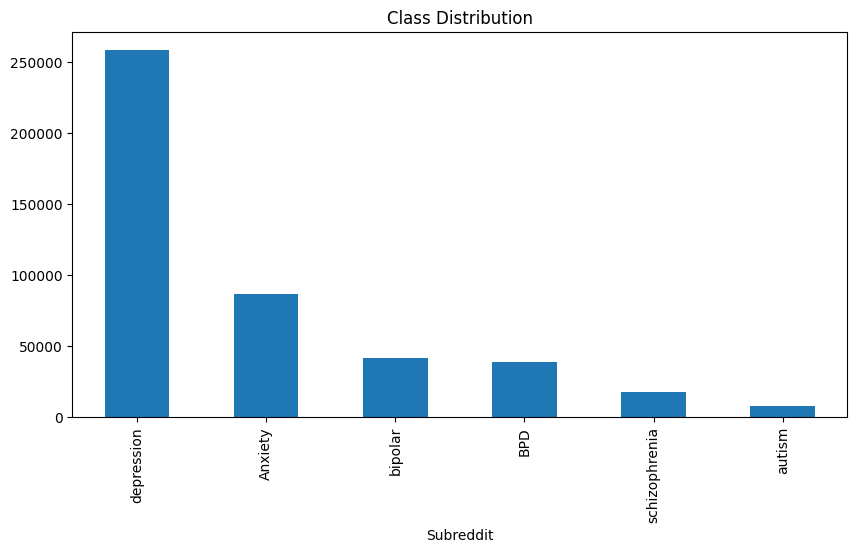

In [6]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

<h3>Text Length Analysis</h3>

In [7]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

count    449081.000000
mean        184.987118
std         224.415133
min           0.000000
25%          60.000000
50%         121.000000
75%         229.000000
max        6597.000000
Name: text_length, dtype: float64

🚨 Key Observations
1️⃣ Highly Skewed Distribution

👉 Most posts are short-medium (50–300 words)

👉 Few extremely long posts → outliers

3️⃣ Long tail problem

👉 Posts with:  

1000+ words

7000+ words

❌ These add noise
❌ Increase TF-IDF sparsity
❌ Hurt Naive Bayes performance

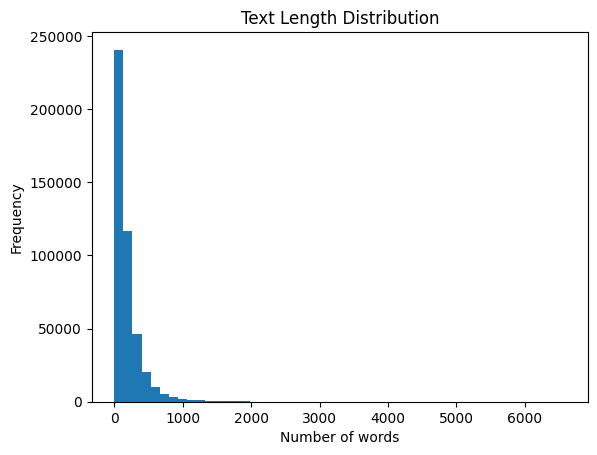

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

🎯 Decision (VERY IMPORTANT)

For Naive Bayes, we will:

✔️ Remove empty texts

✔️ Limit max text length (trim very long posts)

<h3>Removing the Posts with 0 words</h3>

In [9]:
df = df[df["text_length"] > 0]
print(df.shape)

(449002, 4)


<h3>Triming the long text</h3>

In [10]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(449002, 4)

<h3>Merge Title + Text</h3>

In [11]:
df["content"] = df["Title"] + " " + df["Text"]

<h3>Clean Text</h3>

In [12]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [13]:
df["clean_text"]

0         exposure does not work i have struggled with s...
1         panic attack derealization cant go to doctors ...
2         how long can a panic attack last ive been with...
3         stepping stones first time poster long time lu...
4         coping with anxiety over climate change on the...
                                ...                        
488733    religion and paranoid conversation ok ive got ...
488734    isnt this a little weird for being tardive dys...
488735    is this a symptom of schizophrenia or somethin...
488736    anyone seen the new black mirror episode bande...
488737    my girlfriend of over year and i just broke up...
Name: clean_text, Length: 449002, dtype: object

<h3>Remove Stopwords</h3>

In [14]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [15]:
df["clean_text"].head()

0    exposure does work struggled social anxiety ch...
1    panic attack derealization doctors advice appr...
2    long panic attack ive withdrawing medicines la...
3    stepping stones time poster long time lurker i...
4    coping anxiety climate change verge considerin...
Name: clean_text, dtype: object

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000   # instead of 30000      # ↑ bigger vocab → better F1
max_len = 100   # instead of 150         # ↑ longer context → better results

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

2026-04-08 16:32:16.743007: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775665937.013179      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775665937.088143      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775665937.657076      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775665937.657116      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775665937.657119      17 computation_placer.cc:177] computation placer alr

In [17]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Drop rows where 'Subreddit' is NaN to avoid issues with stratification
df_cleaned = df.dropna(subset=['Subreddit'])

# Re-tokenize and pad sequences for the cleaned DataFrame
# The tokenizer was already fitted in a previous step on the full df['clean_text']
# It's important to use the same tokenizer instance.
sequences_cleaned = tokenizer.texts_to_sequences(df_cleaned['clean_text'])
X_cleaned = pad_sequences(sequences_cleaned, maxlen=max_len, padding='post', truncating='post')

# Get the corresponding 'Subreddit' labels for the cleaned data
y_cleaned = df_cleaned['Subreddit']

# Now split the filtered data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned,
    y_cleaned,
    test_size=0.2,
    stratify=y_cleaned,
    random_state=42
)

In [18]:
import numpy as np

embedding_dim = 100
embedding_index = {}

with open("/kaggle/input/datasets/klokeshnaidu/dataset3/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

In [19]:
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words:
        vector = embedding_index.get(word)
        if vector is not None and len(vector) == embedding_dim:
            embedding_matrix[i] = vector

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model():
    model = Sequential()

    # ✅ Fixed Embedding (removed deprecated input_length)
    model.add(Embedding(
        input_dim=max_words,
        output_dim=100,
        weights=[embedding_matrix],
        trainable=False
    ))

    # ✅ Optimized BiGRU (fast + good accuracy)
    model.add(Bidirectional(GRU(64)))

    # ✅ Regularization
    model.add(Dropout(0.3))

    # ✅ Dense layer
    model.add(Dense(32, activation='relu'))

    model.add(Dropout(0.2))

    # ✅ Output layer
    model.add(Dense(1, activation='sigmoid'))

    # ✅ Compile
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )

    return model

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np

# ✅ Early stopping (faster + better)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

results = []

for cls in np.unique(y_train):
    print(f"\n🔥 Training for {cls} vs Rest")

    # Convert to binary
    y_train_bin = (y_train == cls).astype(int)
    y_test_bin = (y_test == cls).astype(int)

    # Check distribution
    class_counts = np.bincount(y_train_bin)
    print("Class distribution:", class_counts)

    # ✅ FIXED SMOTE (no crash)
    try:
        if class_counts[1] < class_counts[0]:
            smote = SMOTE(sampling_strategy='minority', random_state=42)
            X_train_res, y_train_res = smote.fit_resample(X_train, y_train_bin)
            print("✅ SMOTE applied")
        else:
            X_train_res, y_train_res = X_train, y_train_bin
            print("⚠️ SMOTE skipped (majority class)")
    except:
        X_train_res, y_train_res = X_train, y_train_bin
        print("⚠️ SMOTE skipped (safe fallback)")

    # Build model
    model = build_model()

    # Train
    model.fit(
        X_train_res, y_train_res,
        epochs=3,
        batch_size=128,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Predict
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    # Metrics
    report = classification_report(y_test_bin, y_pred, output_dict=True)

    non_class_f1 = report['0']['f1-score']
    class_f1 = report['1']['f1-score']
    acc = accuracy_score(y_test_bin, y_pred)

    print(f"✅ {cls} → F1: {class_f1:.4f}, Acc: {acc:.4f}")

    results.append([cls, non_class_f1, class_f1, acc])


# ✅ Final Results Table
df_results = pd.DataFrame(
    results,
    columns=["Class", "Non-Class F1", "Class F1", "Accuracy"]
)

print("\n📊 FINAL RESULTS:")
print(df_results)


🔥 Training for Anxiety vs Rest
Class distribution: [290217  68984]
✅ SMOTE applied


2026-04-08 16:34:55.384100: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/3
4082/4082 ━━━━━━━━━━━━━━━━━━━━ 476s 116ms/step - accuracy: 0.8399 - loss: 0.3548 - val_accuracy: 0.9532 - val_loss: 0.0982
Epoch 2/3
4082/4082 ━━━━━━━━━━━━━━━━━━━━ 480s 118ms/step - accuracy: 0.9256 - loss: 0.1951 - val_accuracy: 0.9471 - val_loss: 0.1127
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step
✅ Anxiety → F1: 0.7633, Acc: 0.9124

🔥 Training for BPD vs Rest
Class distribution: [328644  30557]
✅ SMOTE applied
Epoch 1/3
4622/4622 ━━━━━━━━━━━━━━━━━━━━ 582s 125ms/step - accuracy: 0.8628 - loss: 0.3080 - val_accuracy: 0.9402 - val_loss: 0.1212
Epoch 2/3
4622/4622 ━━━━━━━━━━━━━━━━━━━━ 537s 116ms/step - accuracy: 0.9451 - loss: 0.1550 - val_accuracy: 0.9658 - val_loss: 0.0725
Epoch 3/3
4622/4622 ━━━━━━━━━━━━━━━━━━━━ 540s 117ms/step - accuracy: 0.9523 - loss: 0.1358 - val_accuracy: 0.9741 - val_loss: 0.0549
2807/2807 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step
✅ BPD → F1: 0.6018, Acc: 0.9419

🔥 Training for autism vs Rest
Class distribution: [353491   5710]
✅ SMOTE applied
Epoch 1/3
4971

In [23]:
df_results = pd.DataFrame(
    results,
    columns=["Class", "Non-Class F1", "Class F1", "Accuracy"]
)

print("\n📊 Final Results:")
print(df_results)


📊 Final Results:
           Class  Non-Class F1  Class F1  Accuracy
0        Anxiety      0.946251  0.763306  0.912395
1            BPD      0.968680  0.601817  0.941927
2         autism      0.988573  0.482474  0.977639
3        bipolar      0.963724  0.639244  0.934076
4     depression      0.834644  0.887144  0.865848
5  schizophrenia      0.976526  0.491162  0.955123


2807/2807 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step


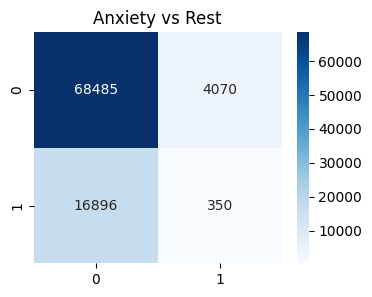

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step


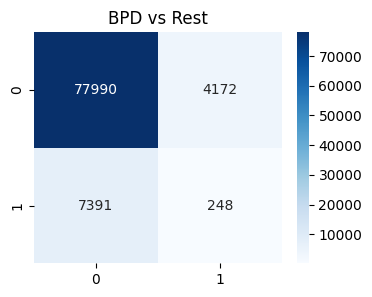

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step


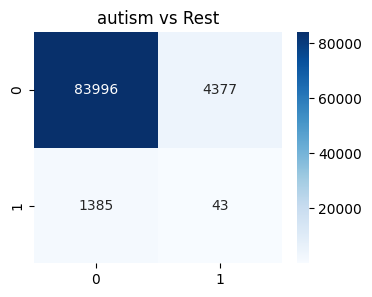

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step


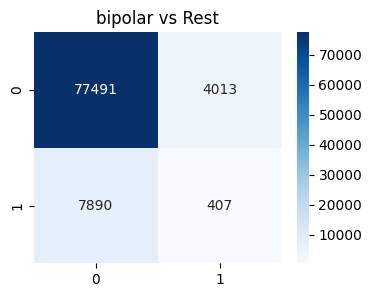

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 33s 12ms/step


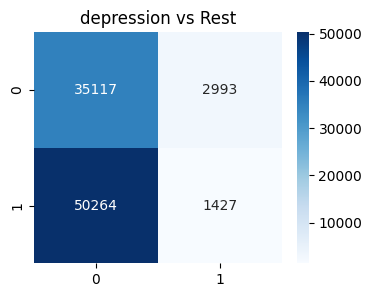

2807/2807 ━━━━━━━━━━━━━━━━━━━━ 32s 11ms/step


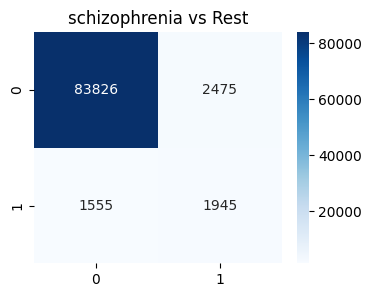

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for cls in np.unique(y_train):
    y_test_bin = (y_test == cls).astype(int)

    y_pred = (model.predict(X_test) > 0.5).astype(int)

    cm = confusion_matrix(y_test_bin, y_pred)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{cls} vs Rest")
    plt.show()